In [1]:
import os
import analysis_utils as au
import quick_metadata_plots as qmplt
import padeopsIO as pio
import matplotlib.pyplot as plt
import numpy as np

sim_folder =  os.path.join(au.DATA_PATH, "F_0017_X_SU_Files/")

In [2]:
xlim = [-5, 20]
ylim =  [-5, 5]
zlim = 0

In [3]:
%matplotlib inline

In [4]:
run_folder = au.get_run_folder(sim_folder, 5)
sim = pio.BudgetIO(run_folder, padeops = True, runid = 0, normalize_origin="turbine", verbose=False)
print("Existing terms: ", sim.existing_terms())

5
Existing terms:  ['ubar', 'vbar', 'wbar', 'uu', 'uv', 'uw', 'vv', 'vw', 'ww', 'pbar', 'tau11', 'tau12', 'tau13', 'tau22', 'tau23', 'tau33', 'pu', 'pv', 'pw', 'uk', 'vk', 'wk', 'ujtau1j', 'ujtau2j', 'ujtau3j', 'Tbar', 'uT', 'vT', 'wT', 'TT', 'wb']


In [12]:
keylab = pio.budgetkey.key_labels()

def plot_phases(field, sim, phases = [], xlim = [-1, 16], ylim = [-2, 2], zlim = 0, diff = False):
    nphases = len(phases)
    even_phases = nphases % 2 == 0
    extents = []
    xkey = ""
    ykey = ""
    if isinstance(xlim, list):
        extents.append(xlim[0])
        extents.append(xlim[1])
        xkey = "x"
    if isinstance(ylim, list):
        extents.append(ylim[0])
        extents.append(ylim[1])
        if xkey == "":
            xkey = "y"
        else:
            ykey = "y"
    if isinstance(zlim, list):
        extents.append(zlim[0])
        extents.append(zlim[1])
        if ykey == "":
            ykey = "z"
    ds = sim.slice(budget_terms=[field], xlim = xlim, ylim = ylim, zlim = zlim, phase = phases[0])
    nx, ny = ds[field].shape
    vals = np.zeros((nx, ny, nphases))
    vals[:, :, 0] = ds[field]
    for (i, phase) in enumerate(phases):
        if i > 0:
            ds = sim.slice(budget_terms=[field], xlim = xlim, ylim = ylim, zlim = zlim, phase = phase)
            vals[:, :, i] = ds[field]

    if diff:
        for (i, phase) in reversed(list(enumerate(phases))):
            vals[:, :, i] = vals[:, :, i] - vals[:, :, 0]
    vmin = np.min(vals)
    vmax = np.max(vals)

    if even_phases:
        nrows = np.maximum(int(nphases / 2), 1)
    else:
        nrows = np.maximum(int(nphases / 2 + 1), 1)
    fig, axs = plt.subplots(nrows, 2, sharex=True, sharey = True, figsize = (12, 6))
    j, k = 0, 0
    for (i, phase) in enumerate(phases):
        if k > 1:
            j += 1
            k = 0
        im = axs[j, k].imshow(vals[:, :, i].T, extent=extents, vmin = vmin, vmax = vmax, origin='lower')
        axs[j, k].set_xlabel(keylab[xkey])
        axs[j, k].set_ylabel(keylab[ykey])
        axs[j, k].set_title(f"Phase = {phase}")
        k += 1
    if len(phases) % 2 != 0:
        fig.delaxes(axs[j, k])
    fig.tight_layout()
    fig.subplots_adjust(right=0.85)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.04, 0.7])
    fig.colorbar(im, cax=cbar_ax)

    return vals

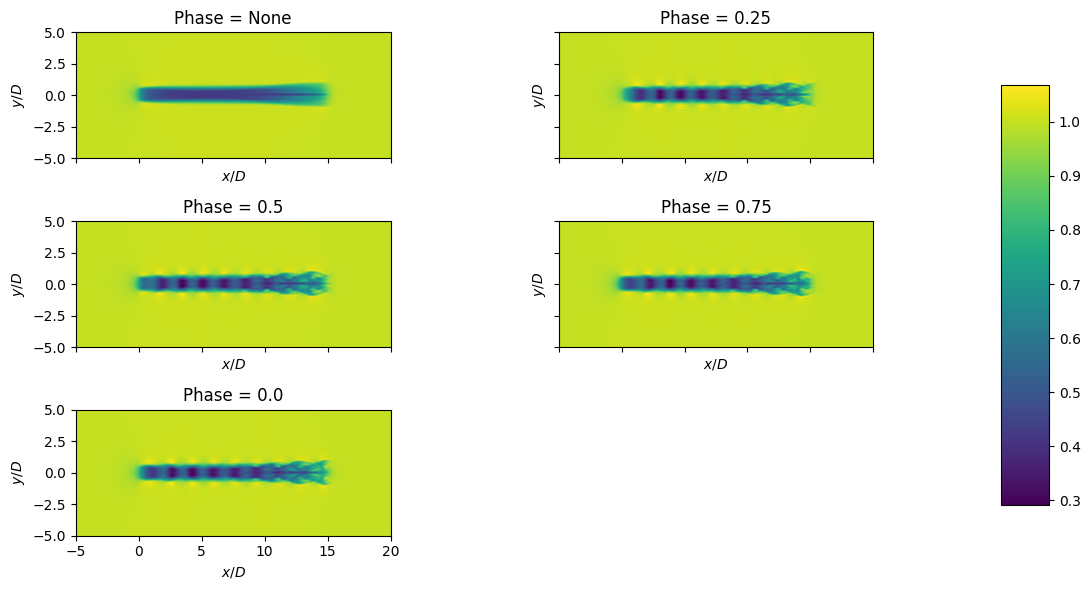

In [13]:
vals = plot_phases('ubar', sim, [None, 0.25, 0.5, 0.75, 0.0], diff = False, xlim = xlim, ylim = ylim, zlim = zlim);

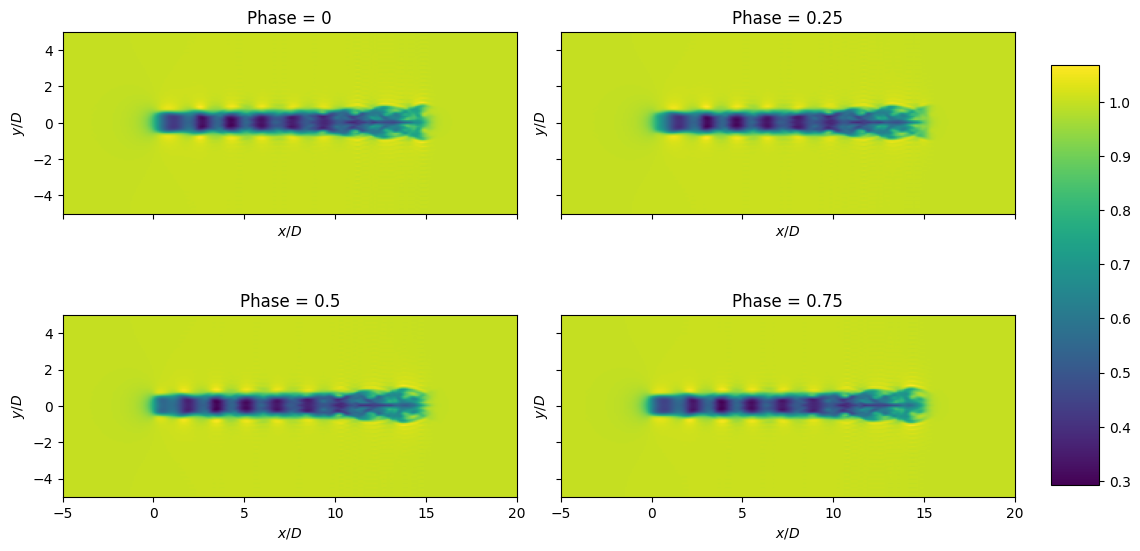

In [14]:
vals = plot_phases('ubar', sim, [0, 0.25, 0.5, 0.75], diff = False, xlim = xlim, ylim = ylim, zlim = zlim);

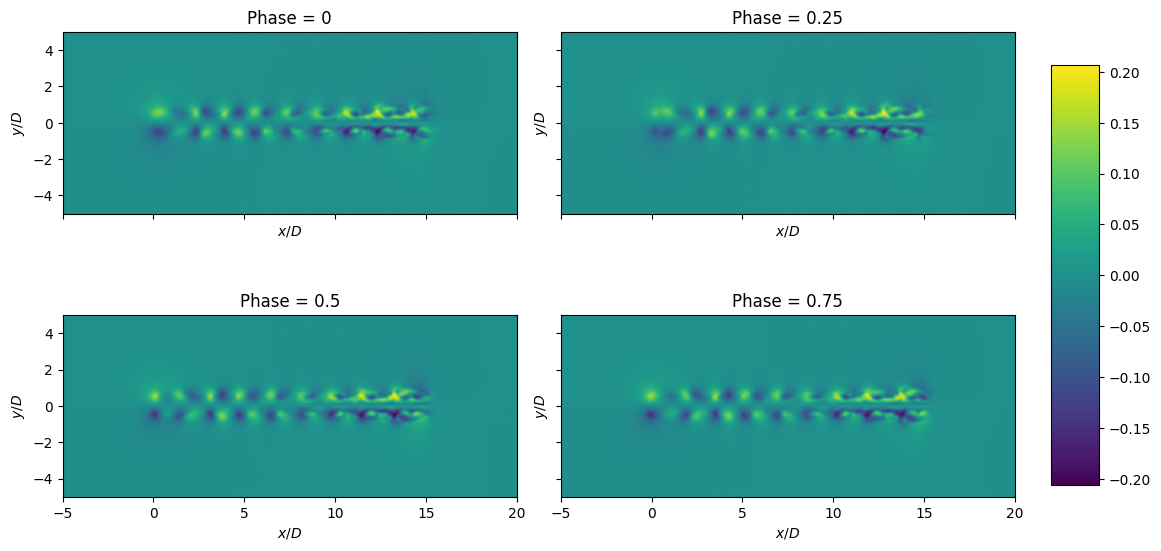

In [15]:
plot_phases('vbar', sim, [0, 0.25, 0.5, 0.75], diff = False, xlim = xlim, ylim = ylim, zlim = zlim);

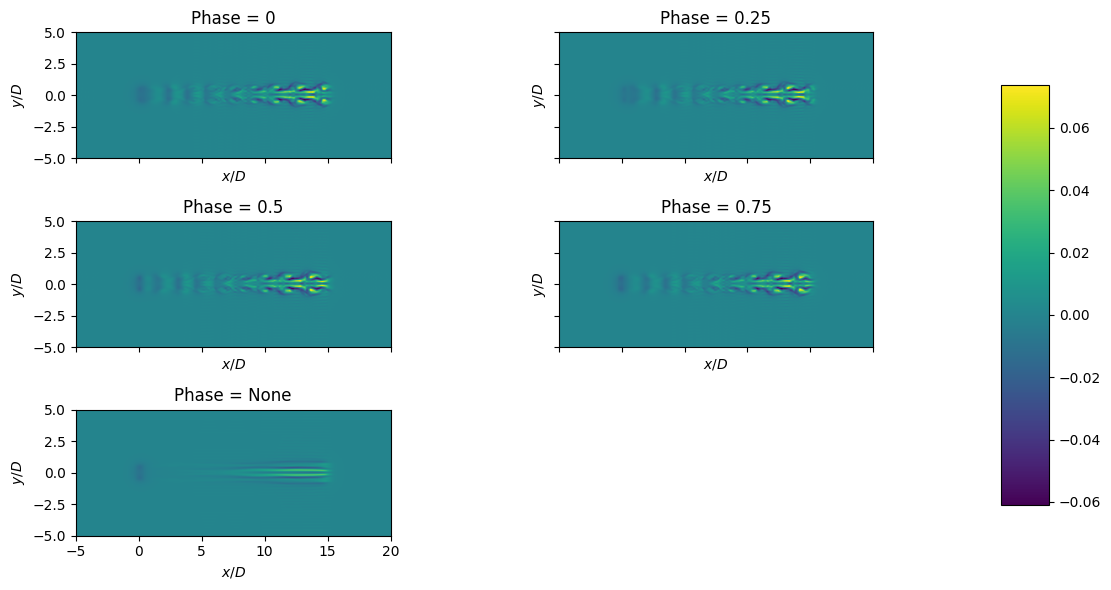

In [ ]:
plot_phases('wbar', sim, [0, 0.25, 0.5, 0.75], diff = False, xlim = xlim, ylim = ylim, zlim = zlim);

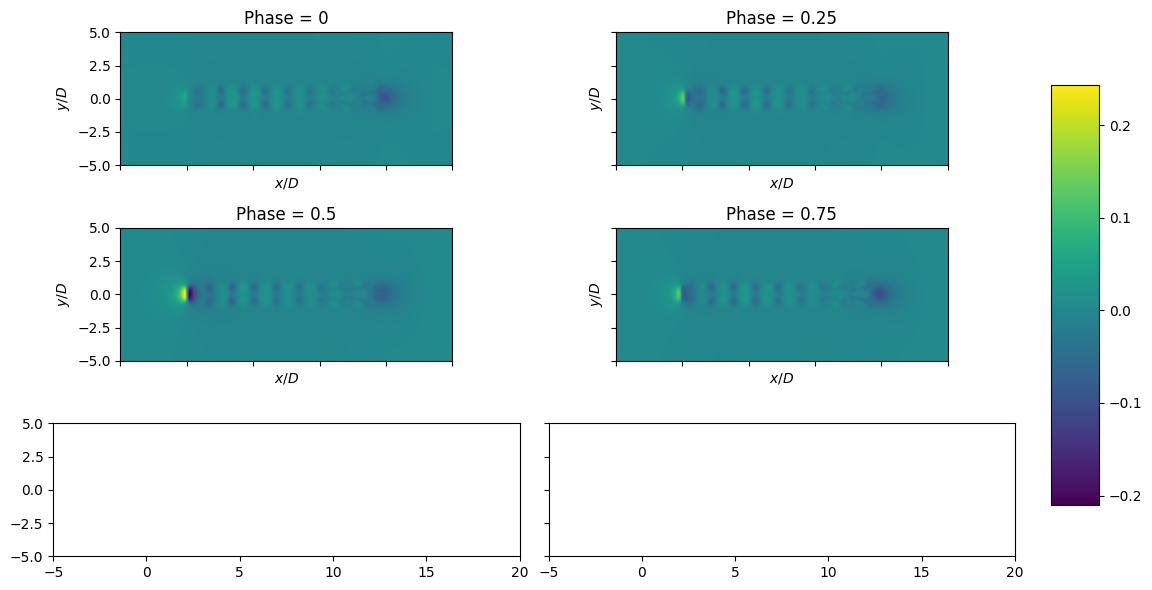

In [10]:
plot_phases('pbar', sim, [0, 0.25, 0.5, 0.75], diff = False, xlim = xlim, ylim = ylim, zlim = zlim);

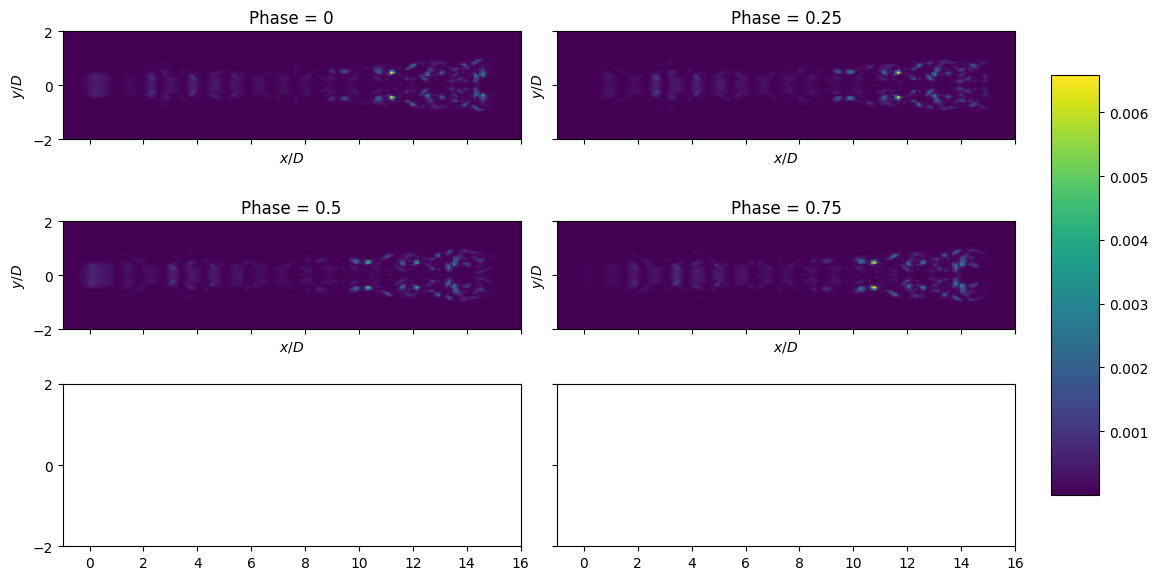

In [11]:
plot_phases('uu', sim, [0, 0.25, 0.5, 0.75]);